In [1]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/fastbat/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
import pandas as pd

mobile = pd.read_csv('../data/mobile2014.csv')
mobile.head()

,ID,Title,Author,ReviewID,Texts,YMD,Sentiment
0,127335,Ripoff don't buy it. Would like to know how to...,Alex Cropper,R112X6CB1GTVF7,Phone does not work. Does not allow outgoing t...,2014-01-14,0
1,161579,I am not satisfied with the product,Monica Heredia,R3MQ3FY4PWPQFM,"I am not satisfied with the iPhone 5s, because...",2014-01-07,0
2,152064,Stay away buy something else,Mark Ducette monte carlo,R1QVAAZ9DWLN5Q,"EATS BATTERIES, BRAND NEW BATTERIES IT EATS FA...",2014-01-28,0
3,180094,wondering,eaamber,R3AR8LYIC3BOI9,I'm wondering if this phone is good or bad I j...,2014-01-15,0
4,180037,virus,pamela,RCYC822DI3R6K,When i got the phone it had a virus on it with...,2014-01-10,0


In [3]:
from nltk import sent_tokenize

print(sent_tokenize(mobile.Texts[0]))

['Phone does not work.', 'Does not allow outgoing text .', 'Incoming calls.', 'Would not disable South African settings.', 'Waste of money']


In [4]:
from nltk.tokenize import word_tokenize
 
word_tokenize(mobile.Texts[0])

['Phone',
 'does',
 'not',
 'work',
 '.',
 'Does',
 'not',
 'allow',
 'outgoing',
 'text',
 '.',
 'Incoming',
 'calls',
 '.',
 'Would',
 'not',
 'disable',
 'South',
 'African',
 'settings',
 '.',
 'Waste',
 'of',
 'money']

## 정규표현식 (Regular Expression)

https://wikidocs.net/21703

- [ ]안에 문자들을 넣으면 그 문자들 중 한 개의 문자와 매치라는 의미를 가집니다. 예를 들어서 정규 표현식이 [abc]라면, a 또는 b또는 c가 들어가있는 문자열과 매치됩니다. 범위를 지정하는 것도 가능합니다. [a-zA-Z]는 알파벳 전부를 의미하며, [0-9]는 숫자 전부를 의미합니다.
- *은 바로 앞의 문자가 0개 이상일 경우를 나타냅니다. 앞의 문자는 존재하지 않을 수도 있으며, 또는 여러 개일 수도 있습니다. 정규 표현식이 ab*c라면 ac, abc, abbc, abbbc 등과 매치할 수 있으며 b의 개수는 무수히 많을 수 있습니다.
- +는 *와 유사합니다. 다른 점은 앞의 문자가 최소 1개 이상이어야 합니다. 정규 표현식이 ab+c라고 한다면 ac는 매치되지 않습니다. 하지만 abc, abbc, abbbc 등과 매치할 수 있으며 b의 개수는 무수히 많을 수 있습니다.
- \w 문자 또는 숫자를 의미합니다. [a-zA-Z0-9]와 의미가 동일합니다.

In [5]:
from nltk.tokenize import RegexpTokenizer

retokenize = RegexpTokenizer("[\w]+")
retokenize.tokenize(mobile.Texts[0])

['Phone',
 'does',
 'not',
 'work',
 'Does',
 'not',
 'allow',
 'outgoing',
 'text',
 'Incoming',
 'calls',
 'Would',
 'not',
 'disable',
 'South',
 'African',
 'settings',
 'Waste',
 'of',
 'money']

In [6]:
mobile["tokenized_sents"] = mobile.apply(
    lambda row: nltk.word_tokenize(str(row["Texts"])), axis=1)
mobile['sents_length'] = mobile.apply(
    lambda row: len(row['tokenized_sents']), axis=1)
mobile.head()

,ID,Title,Author,ReviewID,Texts,YMD,Sentiment,tokenized_sents,sents_length
0,127335,Ripoff don't buy it. Would like to know how to...,Alex Cropper,R112X6CB1GTVF7,Phone does not work. Does not allow outgoing t...,2014-01-14,0,"[Phone, does, not, work, ., Does, not, allow, ...",24
1,161579,I am not satisfied with the product,Monica Heredia,R3MQ3FY4PWPQFM,"I am not satisfied with the iPhone 5s, because...",2014-01-07,0,"[I, am, not, satisfied, with, the, iPhone, 5s,...",63
2,152064,Stay away buy something else,Mark Ducette monte carlo,R1QVAAZ9DWLN5Q,"EATS BATTERIES, BRAND NEW BATTERIES IT EATS FA...",2014-01-28,0,"[EATS, BATTERIES, ,, BRAND, NEW, BATTERIES, IT...",27
3,180094,wondering,eaamber,R3AR8LYIC3BOI9,I'm wondering if this phone is good or bad I j...,2014-01-15,0,"[I, 'm, wondering, if, this, phone, is, good, ...",38
4,180037,virus,pamela,RCYC822DI3R6K,When i got the phone it had a virus on it with...,2014-01-10,0,"[When, i, got, the, phone, it, had, a, virus, ...",21


- 어간 추출

In [7]:
from nltk.stem import PorterStemmer, LancasterStemmer

st1 = PorterStemmer()
st2 =  LancasterStemmer()

words = ["fly", "flies", "flying", "flew", "flown"]

print("Porter Stemmer   :", [st1.stem(w) for w in words])
print("Lancaster Stemmer:", [st2.stem(w) for w in words])

Porter Stemmer   : ['fli', 'fli', 'fli', 'flew', 'flown']
Lancaster Stemmer: ['fly', 'fli', 'fly', 'flew', 'flown']


- 표제어 추출

In [8]:
from nltk.stem import WordNetLemmatizer

lm = WordNetLemmatizer()

[lm.lemmatize(w, pos="v") for w in words]

['fly', 'fly', 'fly', 'fly', 'fly']

- 품사 추출

In [12]:
# part-of-speech
#NNP: 단수 고유명사
#VB: 동사
#VBP: 동사 현재형
#TO: to 전치사
#NN: 명사(단수형 혹은 집합형)
#DT: 관형사

nltk.download('tagsets_json')
nltk.download('averaged_perceptron_tagger_eng')
nltk.help.upenn_tagset("VB")

VB: verb, base form
    ask assemble assess assign assume atone attention avoid bake balkanize
    bank begin behold believe bend benefit bevel beware bless boil bomb
    boost brace break bring broil brush build ...


[nltk_data] Downloading package tagsets_json to
[nltk_data]     /Users/fastbat/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/fastbat/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [13]:
from nltk.tag import pos_tag
tagged_list = pos_tag(word_tokenize(mobile.Texts[0]))
tagged_list

[('Phone', 'NN'),
 ('does', 'VBZ'),
 ('not', 'RB'),
 ('work', 'VB'),
 ('.', '.'),
 ('Does', 'NNP'),
 ('not', 'RB'),
 ('allow', 'VB'),
 ('outgoing', 'VBG'),
 ('text', 'NN'),
 ('.', '.'),
 ('Incoming', 'VBG'),
 ('calls', 'NNS'),
 ('.', '.'),
 ('Would', 'MD'),
 ('not', 'RB'),
 ('disable', 'VB'),
 ('South', 'JJ'),
 ('African', 'JJ'),
 ('settings', 'NNS'),
 ('.', '.'),
 ('Waste', 'NN'),
 ('of', 'IN'),
 ('money', 'NN')]

In [14]:
nouns_list = [t[0] for t in tagged_list if t[1] == "NN"]
nouns_list

['Phone', 'text', 'Waste', 'money']

- 빈도 추출

In [15]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               2000 non-null   int64 
 1   Title            2000 non-null   object
 2   Author           2000 non-null   object
 3   ReviewID         2000 non-null   object
 4   Texts            1999 non-null   object
 5   YMD              2000 non-null   object
 6   Sentiment        2000 non-null   int64 
 7   tokenized_sents  2000 non-null   object
 8   sents_length     2000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 140.8+ KB


In [16]:
data = []

for i in range(len(mobile)):
    data.append(nltk.word_tokenize(str(mobile.Texts[i])))

In [17]:
data2 = sum(data, [])
data2

['Phone',
 'does',
 'not',
 'work',
 '.',
 'Does',
 'not',
 'allow',
 'outgoing',
 'text',
 '.',
 'Incoming',
 'calls',
 '.',
 'Would',
 'not',
 'disable',
 'South',
 'African',
 'settings',
 '.',
 'Waste',
 'of',
 'money',
 'I',
 'am',
 'not',
 'satisfied',
 'with',
 'the',
 'iPhone',
 '5s',
 ',',
 'because',
 'I',
 'bought',
 'an',
 'unlocked',
 'iPhone',
 'but',
 'the',
 'one',
 'that',
 'I',
 'recieved',
 'is',
 'not',
 'unlocked',
 ',',
 'I',
 'am',
 'not',
 'any',
 'more',
 'in',
 'the',
 'US',
 ',',
 'could',
 'you',
 'tell',
 'me',
 'how',
 'Will',
 'you',
 'solve',
 'this',
 'problem.In',
 'despiste',
 'of',
 'your',
 'decision',
 ',',
 'I',
 'want',
 'yo',
 'tell',
 'you',
 'I',
 'am',
 'completely',
 'not',
 'satisfied',
 'with',
 'the',
 'product',
 '.',
 'EATS',
 'BATTERIES',
 ',',
 'BRAND',
 'NEW',
 'BATTERIES',
 'IT',
 'EATS',
 'FASTER',
 ',',
 'LG',
 'KNOWN',
 'PROBLEM',
 'WITH',
 'THIS',
 'MODEL',
 'THOUGHT',
 'IT',
 'WAS',
 'MY',
 'DAUGHTER',
 ',',
 'BOY',
 'WAS',
 'I

In [18]:
from collections import Counter

counts = Counter(data2)
mcounts = counts.most_common(20)
mcounts

[('.', 7047),
 ('the', 6120),
 (',', 5299),
 ('I', 4848),
 ('and', 4192),
 ('it', 3762),
 ('to', 3684),
 ('phone', 3554),
 ('a', 3406),
 ('is', 2768),
 ('this', 1932),
 ('for', 1817),
 ('of', 1686),
 ('not', 1508),
 ('!', 1500),
 ('my', 1420),
 ('with', 1384),
 ('in', 1355),
 ('that', 1334),
 ('was', 1304)]

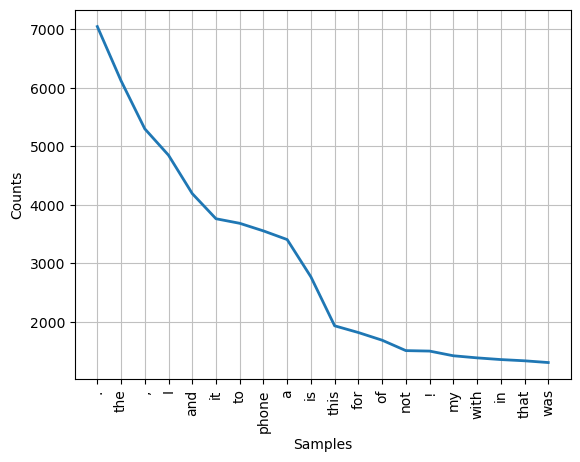

In [19]:
from nltk import Text

text = Text(data2)

import matplotlib.pyplot as plt 

text.plot(20)   # frequency plot
plt.show()

Displaying 25 of 3742 matches:
                                     Phone does not work . Does not allow outgo
WAS I WRONG . I 'm wondering if this phone is good or bad I just bought him and
iews and bad and does it take att go phone sim card or a special kind please le
nd please let me know When i got the phone it had a virus on it within 3 days t
 had a virus on it within 3 days the phone stopped working all together . Have 
pped working all together . Have the phone with Verizon and Sprint . Sprint has
 than other manufacturers - love the phone on Verizon - hate it on Sprint . Spr
rint . Sprint would not activate the phone they said it was lost or stolen . Th
hey said it was lost or stolen . The phone was in great shape when I received i
ould not be activated I looked for a phone # to call to see if I was doing some
 well . The carma is very bad on the phone and it drop calls the volume does n'
always get locked I 've only had the phone for 2 months and now it will no long
o longer 

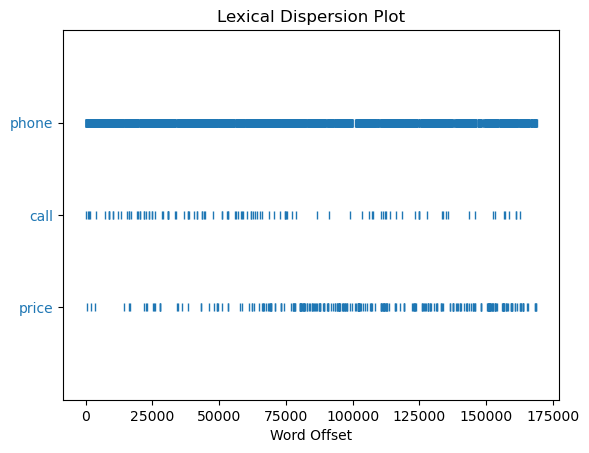

In [20]:
text.dispersion_plot(["phone", "call", "price"])

text.concordance("phone")

### 명사(NN)만 추출

In [21]:
from nltk import FreqDist

stopwords = ['I', 'i', 'this', 'the', 'a']
mobile_tokens = pos_tag(retokenize.tokenize(str(data2)))

names_list = [t[0] for t in mobile_tokens if t[1] 
              == "NN" and t[0] not in stopwords]

fd_names = FreqDist(names_list)

In [22]:
names_list

['Phone',
 'Waste',
 'money',
 'iPhone',
 'iPhone',
 'one',
 'problem',
 'despiste',
 'decision',
 'product',
 'phone',
 'phone',
 'card',
 'kind',
 'please',
 'phone',
 'virus',
 'phone',
 'phone',
 'issue',
 'shut',
 'network',
 'network',
 'prone',
 'issue',
 'phone',
 'phone',
 'phone',
 'shape',
 'phone',
 'something',
 'return',
 'process',
 'carma',
 'phone',
 'volume',
 't',
 'work',
 'phone',
 'phone',
 'phone',
 'price',
 'bill',
 'month',
 'map',
 'system',
 'date',
 'phone',
 'fun',
 'camera',
 'warranty',
 'phone',
 'phone',
 'lesson',
 'phone',
 'date',
 'os',
 'tone',
 'song',
 'bb',
 'preset',
 'radio',
 'thing',
 'date',
 'solution',
 'phone',
 'phone',
 't',
 'policy',
 'month',
 'phone',
 'box',
 'card',
 'phone',
 'bit',
 'nothing',
 'everything',
 'phone',
 'camera',
 'camera',
 'apps',
 'tech',
 'savvy',
 'person',
 'product',
 'alot',
 'minute',
 'minder',
 'figure',
 'book',
 'anything',
 'version',
 'experience',
 'sound',
 'back',
 'order',
 'money',
 'message

In [23]:
fd_names.N(), fd_names["Phone"], fd_names.freq("Phone")

(23878, 12, 0.000502554652818494)

In [24]:
fd_names.most_common(5)

[('phone', 3623),
 ('screen', 394),
 ('battery', 371),
 ('camera', 323),
 ('time', 299)]

- 워드 클라우드

In [26]:
!pip install wordcloud

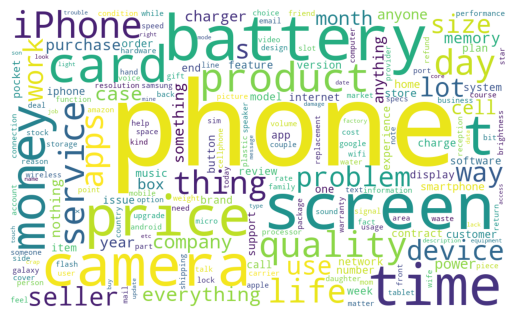

In [27]:
from wordcloud import WordCloud

wc = WordCloud(width=1000, height=600, background_color="white", random_state=0)
plt.imshow(wc.generate_from_frequencies(fd_names))
plt.axis("off")
plt.show()

### 단어 문서 매트릭스 

In [28]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

mobile = pd.read_csv('../data/mobile2014.csv')

# NA 값이 들어 있는 문장에 ' ' (비어 있는) 문장을 입력 
mobile.Texts[mobile.Texts.isna()]
mobile.Texts = mobile.Texts.fillna('')

#tokenizer to remove unwanted elements from out data like symbols and numbers
token = RegexpTokenizer(r'[a-zA-Z]+')

cv = CountVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,1),
    tokenizer = token.tokenize
)

text_counts= cv.fit_transform(mobile['Texts'])

/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [29]:
text_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 54514 stored elements and shape (2000, 7178)>

In [30]:
vocab = cv.get_feature_names_out()
vocab[:10]

array(['aah', 'aap', 'aarp', 'abandant', 'abd', 'ability', 'able',
       'abombada', 'aboutprice', 'abroad'], dtype=object)

- 단어의 문서 전체 등장 횟수

In [31]:
import numpy as np
dist = np.sum(text_counts, axis=0)

for tag, count in zip(vocab, dist):
    print(count, tag)

pd.DataFrame(dist, columns=vocab)

[[1 1 2 ... 3 4 1]] aah


,aah,aap,aarp,abandant,abd,ability,able,abombada,aboutprice,abroad,...,zillion,zip,zippy,zoes,zoey,zone,zoom,zooming,zte,zvc
0,1,1,2,1,1,17,96,1,1,2,...,1,2,3,1,1,6,4,3,4,1


- 단어 문서 매트릭스

In [32]:
pd.DataFrame(text_counts[:100].toarray(), columns=vocab).head()

,aah,aap,aarp,abandant,abd,ability,able,abombada,aboutprice,abroad,...,zillion,zip,zippy,zoes,zoey,zone,zoom,zooming,zte,zvc
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- binary 단어 문서 매트릭스

In [33]:
cv_binary = CountVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,1),
    binary = True,
    tokenizer = token.tokenize
)

text_counts= cv_binary.fit_transform(mobile['Texts'])

/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [34]:
vocab = cv_binary.get_feature_names_out()

pd.DataFrame(text_counts[110:120].toarray(), columns=vocab)

,aah,aap,aarp,abandant,abd,ability,able,abombada,aboutprice,abroad,...,zillion,zip,zippy,zoes,zoey,zone,zoom,zooming,zte,zvc
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- TF*IDF 

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,1),
    tokenizer = token.tokenize
)

text_tfidf= tfidf.fit_transform(mobile['Texts'])

/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [36]:
vocab = tfidf.get_feature_names_out()
vocab[:10]

array(['aah', 'aap', 'aarp', 'abandant', 'abd', 'ability', 'able',
       'abombada', 'aboutprice', 'abroad'], dtype=object)

In [37]:
pd.DataFrame(text_tfidf[110:120].toarray(), columns=vocab)

,aah,aap,aarp,abandant,abd,ability,able,abombada,aboutprice,abroad,...,zillion,zip,zippy,zoes,zoey,zone,zoom,zooming,zte,zvc
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.079418,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.000000,0.144802,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- n gram

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,2),
    tokenizer = token.tokenize
)

text_tfidf= tfidf.fit_transform(mobile['Texts'])

/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [39]:
vocab = tfidf.get_feature_names_out()
vocab[:10]

array(['aah', 'aah color', 'aap', 'aap s', 'aarp', 'aarp members',
       'aarp web', 'abandant', 'abandant application', 'abd'],
      dtype=object)

In [40]:
pd.DataFrame(text_tfidf[110:120].toarray(), columns=vocab)

,aah,aah color,aap,aap s,aarp,aarp members,aarp web,abandant,abandant application,abd,...,zooming,zooming photo,zooming photos,zte,zte illustra,zte os,zte phone,zte valet,zvc,zvc update
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 연습문제 

### 감성 분석 - Multinomial NB

In [41]:
import nltk
import pandas as pd

mobile = pd.read_csv('../data/mobile2014.csv')
mobile.head()

,ID,Title,Author,ReviewID,Texts,YMD,Sentiment
0,127335,Ripoff don't buy it. Would like to know how to...,Alex Cropper,R112X6CB1GTVF7,Phone does not work. Does not allow outgoing t...,2014-01-14,0
1,161579,I am not satisfied with the product,Monica Heredia,R3MQ3FY4PWPQFM,"I am not satisfied with the iPhone 5s, because...",2014-01-07,0
2,152064,Stay away buy something else,Mark Ducette monte carlo,R1QVAAZ9DWLN5Q,"EATS BATTERIES, BRAND NEW BATTERIES IT EATS FA...",2014-01-28,0
3,180094,wondering,eaamber,R3AR8LYIC3BOI9,I'm wondering if this phone is good or bad I j...,2014-01-15,0
4,180037,virus,pamela,RCYC822DI3R6K,When i got the phone it had a virus on it with...,2014-01-10,0


In [42]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         2000 non-null   int64 
 1   Title      2000 non-null   object
 2   Author     2000 non-null   object
 3   ReviewID   2000 non-null   object
 4   Texts      1999 non-null   object
 5   YMD        2000 non-null   object
 6   Sentiment  2000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 109.5+ KB


In [43]:
mobile.Sentiment.value_counts()

Sentiment
0    1000
1    1000
Name: count, dtype: int64

In [44]:
# NA 값이 들어 있는 문장에 ' ' (비어 있는) 문장을 입력 
mobile.Texts[mobile.Texts.isna()]
mobile.Texts = mobile.Texts.fillna('')

In [45]:
mobile.Sentiment = pd.Categorical(mobile.Sentiment)
Sentiment_count = mobile.groupby('Sentiment').count()
Sentiment_count

/var/folders/s2/44hkpd2s1ps_qkx7j_pvkwkh0000gn/T/ipykernel_18828/3846764157.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Sentiment_count = mobile.groupby('Sentiment').count()


,ID,Title,Author,ReviewID,Texts,YMD
Sentiment,,,,,,
0,1000,1000,1000,1000,1000,1000
1,1000,1000,1000,1000,1000,1000


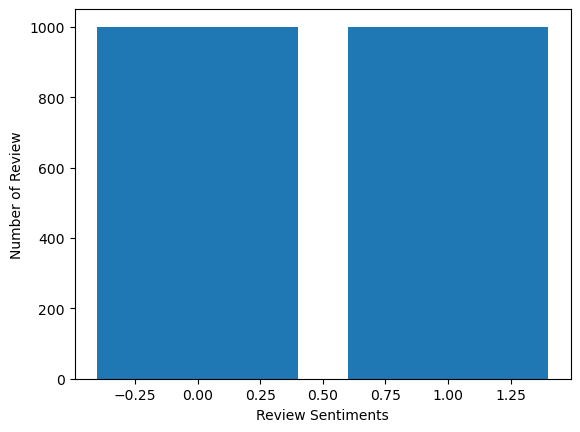

In [46]:
import matplotlib.pyplot as plt

plt.bar(Sentiment_count.index.values, Sentiment_count['ID'])
plt.xlabel('Review Sentiments')
plt.ylabel('Number of Review')
plt.show()

- 빈도 기반 단어 문서 매트릭스 

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

token = RegexpTokenizer(r'[a-zA-Z0-9]+')
cv = CountVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,1),
    tokenizer = token.tokenize
)

text_counts= cv.fit_transform(mobile['Texts'])

/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    text_counts, mobile['Sentiment'], test_size=0.3)

- Multinomial NB 

In [49]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

clf = MultinomialNB().fit(X_train, y_train)

predicted= clf.predict(X_test)
print("MultinomialNB Accuracy:",metrics.accuracy_score(y_test, predicted))

MultinomialNB Accuracy: 0.895


In [50]:
from sklearn.model_selection import cross_val_score 

score = cross_val_score(clf, text_counts, mobile['Sentiment'], scoring='accuracy', cv=5)
print("MultinomialNB 5 CV Accuracy:", score.mean())

MultinomialNB 5 CV Accuracy: 0.899


- tf idf 기반 단어 문서 매트릭스

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf=TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,1),
    tokenizer = token.tokenize
)

text_tf= tf.fit_transform(mobile['Texts'])

/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    text_tf, mobile['Sentiment'], test_size=0.3)

In [53]:
clf = MultinomialNB().fit(X_train, y_train)

predicted= clf.predict(X_test)
print("MultinomialNB Accuracy:",metrics.accuracy_score(y_test, predicted))

MultinomialNB Accuracy: 0.9133333333333333


In [54]:
score = cross_val_score(clf, text_tf, mobile['Sentiment'], scoring='accuracy', cv=5)
print("MultinomialNB 5 CV Accuracy:", score.mean())

MultinomialNB 5 CV Accuracy: 0.9145


- tf idf with bigram

In [55]:
tf=TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,2),
    tokenizer = token.tokenize
)

text_tf= tf.fit_transform(mobile['Texts'])

X_train, X_test, y_train, y_test = train_test_split(
    text_tf, mobile['Sentiment'], test_size=0.3)

clf = MultinomialNB().fit(X_train, y_train)

predicted= clf.predict(X_test)
print("MultinomialNB Accuracy:",metrics.accuracy_score(y_test, predicted))

MultinomialNB Accuracy: 0.8983333333333333


/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [56]:
score = cross_val_score(clf, text_tf, mobile['Sentiment'], scoring='accuracy', cv=5)
print("MultinomialNB 5 CV Accuracy:", score.mean())

MultinomialNB 5 CV Accuracy: 0.9135


- Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(X_train, y_train)

predicted= logreg.predict(X_test)
print("Logistic Regression Accuracy:",metrics.accuracy_score(y_test, predicted))

Logistic Regression Accuracy: 0.8933333333333333


In [58]:
score = cross_val_score(logreg, text_tf, mobile['Sentiment'], scoring='accuracy', cv=5)
print("LogisticRegression 5 CV Accuracy:", score.mean())

LogisticRegression 5 CV Accuracy: 0.8985


- Bernoulli NB

In [59]:
cv_binary = CountVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range = (1,1),
    binary = True,
    tokenizer = token.tokenize
)

text_counts= cv_binary.fit_transform(mobile['Texts'])

/Users/fastbat/opt/anaconda3.1/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [60]:
from sklearn.naive_bayes import BernoulliNB

X_train, X_test, y_train, y_test = train_test_split(
    text_tf, mobile['Sentiment'], test_size=0.3)

clf = BernoulliNB().fit(X_train, y_train)

predicted= clf.predict(X_test)
print("BernoulliNB Accuracy:",metrics.accuracy_score(y_test, predicted))

BernoulliNB Accuracy: 0.6883333333333334


In [61]:
score = cross_val_score(clf, text_counts, mobile['Sentiment'], scoring='accuracy', cv=5)
print("BernoulliNB 5 CV Accuracy:", score.mean())

BernoulliNB 5 CV Accuracy: 0.8265
